E-commerce recommendation system

Step 1 - Importing important libraries and tools

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time, os, re, pickle
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD, PCA, NMF
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, precision_recall_curve
)
import scipy.sparse as sp


Step 2 - Load Datasets

In [5]:
import os
data_path = 'data'

amazon      = pd.read_csv(os.path.join(data_path, 'amazon.csv'))
customer    = pd.read_csv(os.path.join(data_path, 'ecommerce_customer_data_custom_ratios.csv'))
beauty      = pd.read_csv(os.path.join(data_path, 'ratings_Beauty.csv'))
electronics = pd.read_csv(os.path.join(data_path, 'ratings_Electronics (1).csv'),
                          names=['UserId', 'ProductId', 'Rating', 'Timestamp'])

datasets = {'Amazon': amazon, 'Customer': customer, 'Beauty': beauty, 'Electronics': electronics}

for name, df in datasets.items():
    print(f"{name:15s} | shape: {str(df.shape):18s} | nulls: {df.isnull().sum().sum()}")

Amazon          | shape: (1465, 16)         | nulls: 2
Customer        | shape: (250000, 13)       | nulls: 47596
Beauty          | shape: (2023070, 4)       | nulls: 0
Electronics     | shape: (7824482, 4)       | nulls: 0


Step 3 - Exploratory Data Analysis (EDA)

In [6]:
# ── Quick overview of all datasets ──────────────────────────────────────────
for name, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape   : {df.shape}")
    print(f"  Columns : {list(df.columns)}")
    print(f"  Dtypes  :\n{df.dtypes.to_string()}")
    print(f"\n  Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string() or '  None'}")
    print(f"\n  Sample:\n{df.head(2).to_string()}")


  Amazon
  Shape   : (1465, 16)
  Columns : ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']
  Dtypes  :
product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object

  Missing values:
rating_count    2

  Sample:
   product_id                                                                                                                                                              

In [7]:
# ── Numeric stats ────────────────────────────────────────────────────────────
for name, df in datasets.items():
    num = df.select_dtypes(include='number')
    if not num.empty:
        print(f"\n── {name} ──")
        display(num.describe().round(2))


── Customer ──


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00,250000.00,250000.00,250000.00,250000.00,202404.0,250000.00,250000.0
mean,25004.04,254.66,3.00,2725.37,43.94,0.5,43.94,0.2
std,14428.28,141.57,1.41,1442.93,15.35,0.5,15.35,0.4
min,1.00,10.00,1.00,100.00,18.00,0.0,18.00,0.0
25%,12497.75,132.00,2.00,1477.00,31.00,0.0,31.00,0.0
50%,25018.00,255.00,3.00,2724.00,44.00,0.0,44.00,0.0
75%,37506.00,377.00,4.00,3974.00,57.00,1.0,57.00,0.0
max,50000.00,500.00,5.00,5350.00,70.00,1.0,70.00,1.0



── Beauty ──


,Rating,Timestamp
count,2023070.00,2.023070e+06
mean,4.15,1.360389e+09
std,1.31,4.611860e+07
min,1.00,9.087552e+08
25%,4.00,1.350259e+09
50%,5.00,1.372810e+09
75%,5.00,1.391472e+09
max,5.00,1.406074e+09



── Electronics ──


,Rating,Timestamp
count,7824482.00,7.824482e+06
mean,4.01,1.338178e+09
std,1.38,6.900426e+07
min,1.00,9.127296e+08
25%,3.00,1.315354e+09
50%,5.00,1.361059e+09
75%,5.00,1.386115e+09
max,5.00,1.406074e+09


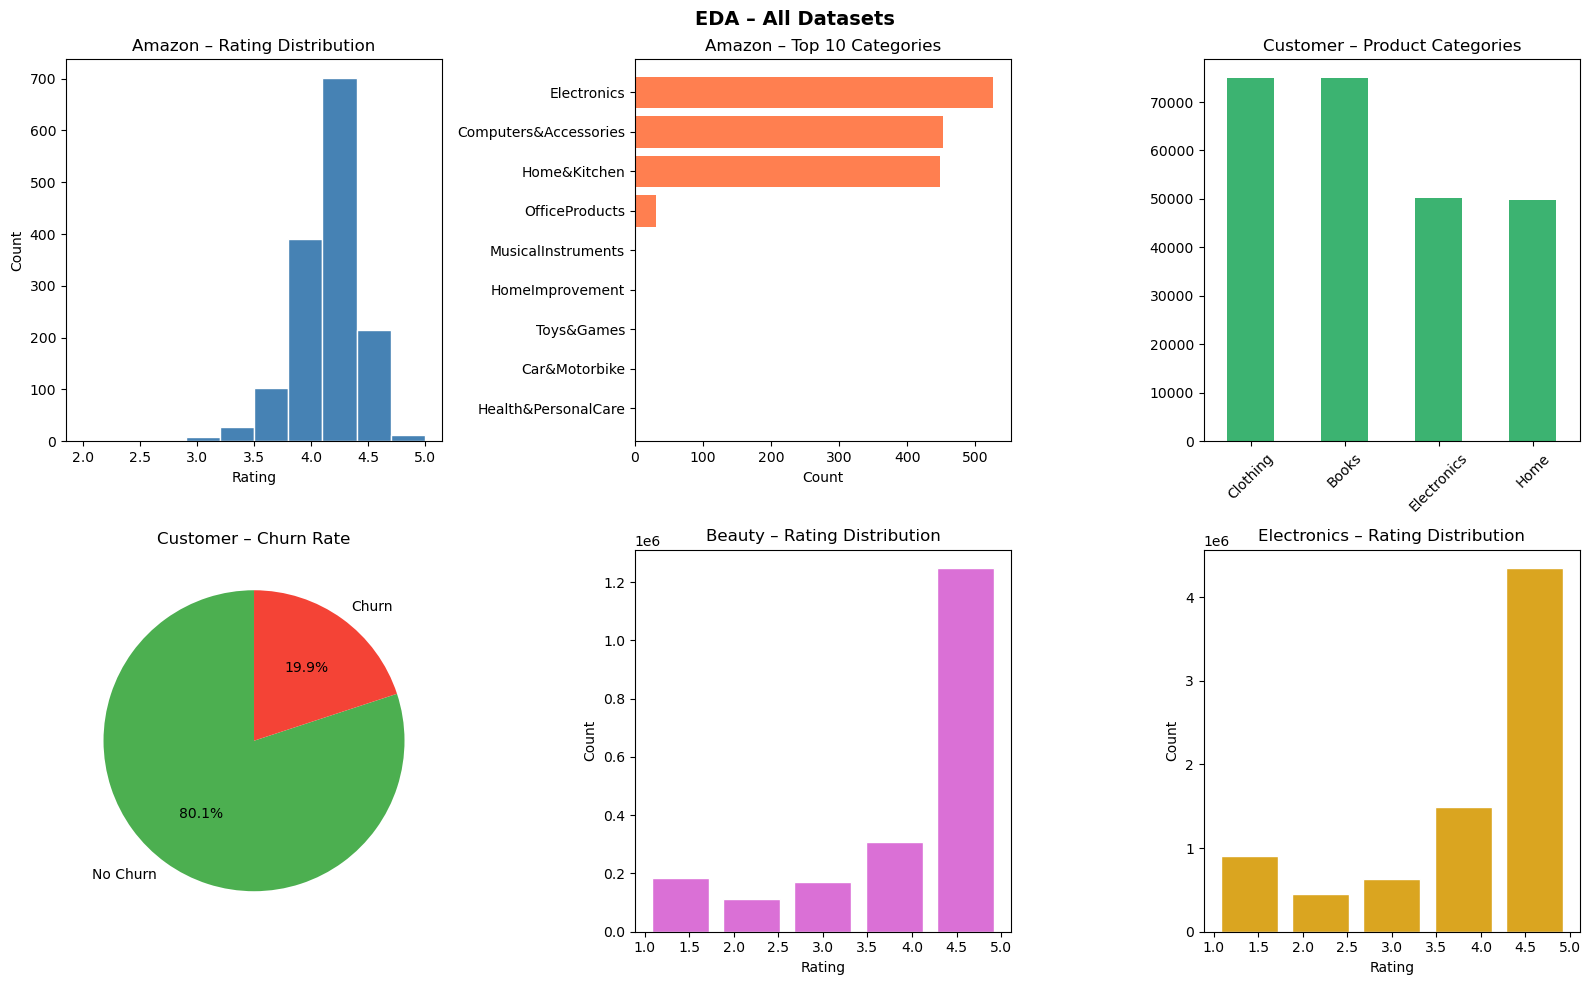

In [8]:
# ── Visualizations ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA – All Datasets', fontsize=14, fontweight='bold')

# 1. Amazon: clean rating column (strip non-numeric) and plot distribution
amazon['rating_num'] = pd.to_numeric(amazon['rating'], errors='coerce')
axes[0, 0].hist(amazon['rating_num'].dropna(), bins=10, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Amazon – Rating Distribution')
axes[0, 0].set_xlabel('Rating'); axes[0, 0].set_ylabel('Count')

# 2. Amazon: top 10 main categories
amazon['main_cat'] = amazon['category'].str.split('|').str[0]
top_cats = amazon['main_cat'].value_counts().head(10)
axes[0, 1].barh(top_cats.index[::-1], top_cats.values[::-1], color='coral')
axes[0, 1].set_title('Amazon – Top 10 Categories')
axes[0, 1].set_xlabel('Count')

# 3. Customer: product category distribution
customer['Product Category'].value_counts().plot(kind='bar', ax=axes[0, 2], color='mediumseagreen')
axes[0, 2].set_title('Customer – Product Categories')
axes[0, 2].set_xlabel(''); axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Customer: churn rate
churn_counts = customer['Churn'].value_counts()
axes[1, 0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
               colors=['#4CAF50', '#F44336'], startangle=90)
axes[1, 0].set_title('Customer – Churn Rate')

# 5. Beauty ratings distribution
axes[1, 1].hist(beauty['Rating'], bins=5, color='orchid', edgecolor='white', rwidth=0.8)
axes[1, 1].set_title('Beauty – Rating Distribution')
axes[1, 1].set_xlabel('Rating'); axes[1, 1].set_ylabel('Count')

# 6. Electronics ratings distribution
axes[1, 2].hist(electronics['Rating'], bins=5, color='goldenrod', edgecolor='white', rwidth=0.8)
axes[1, 2].set_title('Electronics – Rating Distribution')
axes[1, 2].set_xlabel('Rating'); axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [9]:
# ── Sparsity & user/item counts for rating datasets ─────────────────────────
for name, df in [('Beauty', beauty), ('Electronics', electronics)]:
    n_users    = df['UserId'].nunique()
    n_items    = df['ProductId'].nunique()
    n_ratings  = len(df)
    sparsity   = 1 - n_ratings / (n_users * n_items)
    print(f"{name}: {n_users} users | {n_items} items | {n_ratings:,} ratings | sparsity: {sparsity:.4%}")

print(f"\nAmazon:   {amazon['user_id'].nunique()} unique users | {amazon['product_id'].nunique()} unique products")
print(f"Customer: {customer['Customer ID'].nunique()} unique customers | payment methods: {customer['Payment Method'].unique()}")

Beauty: 1210271 users | 249274 items | 2,023,070 ratings | sparsity: 99.9993%
Electronics: 4201696 users | 476002 items | 7,824,482 ratings | sparsity: 99.9996%

Amazon:   1194 unique users | 1351 unique products
Customer: 49673 unique customers | payment methods: ['Credit Card' 'PayPal' 'Cash' 'Crypto']


Step 4 - Data Cleaning

In [10]:
# ── Amazon ───────────────────────────────────────────────────────────────────
def clean_inr(s):
    return pd.to_numeric(s.astype(str).str.replace(r'[₹,]', '', regex=True), errors='coerce')

amazon['discounted_price']    = clean_inr(amazon['discounted_price'])
amazon['actual_price']        = clean_inr(amazon['actual_price'])
amazon['discount_percentage'] = pd.to_numeric(amazon['discount_percentage'].astype(str).str.replace('%',''), errors='coerce')
amazon['rating_count']        = pd.to_numeric(amazon['rating_count'].astype(str).str.replace(',',''), errors='coerce')
amazon['rating']              = pd.to_numeric(amazon['rating'], errors='coerce')
amazon['main_category']       = amazon['category'].str.split('|').str[0]

amazon.dropna(subset=['rating', 'rating_count'], inplace=True)
amazon.drop(columns=['about_product', 'img_link', 'product_link', 'rating_num', 'main_cat'], inplace=True, errors='ignore')

print("Amazon cleaned:", amazon.shape)
print(amazon[['discounted_price','actual_price','discount_percentage','rating','rating_count']].dtypes)

Amazon cleaned: (1462, 14)
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count           float64
dtype: object


In [11]:
# ── Customer ─────────────────────────────────────────────────────────────────
customer['Purchase Date'] = pd.to_datetime(customer['Purchase Date'])
customer['Returns']       = customer['Returns'].fillna(0).astype(int)

customer.drop(columns=['Age', 'Customer Name'], inplace=True)   # Age duplicates Customer Age; Name is PII

customer.columns = (customer.columns
                    .str.strip().str.lower().str.replace(' ', '_'))

print("Customer cleaned:", customer.shape)
print(customer.dtypes)
print(customer.head(2))

Customer cleaned: (250000, 11)
customer_id                       int64
purchase_date            datetime64[ns]
product_category                 object
product_price                     int64
quantity                          int64
total_purchase_amount             int64
payment_method                   object
customer_age                      int64
returns                           int32
gender                           object
churn                             int64
dtype: object
   customer_id       purchase_date product_category  product_price  quantity  \
0        46251 2020-09-08 09:38:32      Electronics             12         3   
1        46251 2022-03-05 12:56:35             Home            468         4   

   total_purchase_amount payment_method  customer_age  returns gender  churn  
0                    740    Credit Card            37        0   Male      0  
1                   2739         PayPal            37        0   Male      0  


In [12]:
# ── Beauty & Electronics ─────────────────────────────────────────────────────
for df in [beauty, electronics]:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Filter to users & items with at least 5 ratings (reduce sparsity for CF)
def filter_min_interactions(df, min_count=5):
    for col in ['UserId', 'ProductId']:
        counts = df[col].value_counts()
        df = df[df[col].isin(counts[counts >= min_count].index)]
    return df.reset_index(drop=True)

beauty_cf      = filter_min_interactions(beauty)
electronics_cf = filter_min_interactions(electronics)

print(f"Beauty      raw: {beauty.shape}  →  filtered: {beauty_cf.shape}")
print(f"Electronics raw: {electronics.shape}  →  filtered: {electronics_cf.shape}")

Beauty      raw: (2023070, 4)  →  filtered: (313823, 4)
Electronics raw: (7824482, 4)  →  filtered: (1936886, 4)


In [13]:
# ── Encode user/item IDs for matrix indexing ─────────────────────────────────
le_user, le_item = LabelEncoder(), LabelEncoder()

for name, df in [('beauty_cf', beauty_cf), ('electronics_cf', electronics_cf)]:
    df['user_idx'] = le_user.fit_transform(df['UserId'])
    df['item_idx'] = le_item.fit_transform(df['ProductId'])

# ── Post-cleaning summary ─────────────────────────────────────────────────────
print("Final shapes after cleaning")
for name, df in [('Amazon', amazon), ('Customer', customer),
                 ('Beauty (CF)', beauty_cf), ('Electronics (CF)', electronics_cf)]:
    print(f"  {name:20s}: {str(df.shape):18s} | nulls: {df.isnull().sum().sum()}")

Final shapes after cleaning
  Amazon              : (1462, 14)         | nulls: 0
  Customer            : (250000, 11)       | nulls: 0
  Beauty (CF)         : (313823, 6)        | nulls: 0
  Electronics (CF)    : (1936886, 6)       | nulls: 0


Step 5 - Model Selection & Train-Test Split

In [14]:
# Install libraries that require compilation (run once)
!pip install lightfm scikit-surprise -q


[notice] A new release of pip is available: 23.3.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# ── Train / Test Split ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# ── Collaborative Filtering – KNN (sklearn) ──────────────────────────────────
from sklearn.neighbors import NearestNeighbors          # already in Step 1

# ── Collaborative Filtering – Surprise (SVD, SVD++, KNN variants) ────────────
from surprise import (
    SVD,            # Matrix factorization (Funk SVD)
    SVDpp,          # SVD++ (implicit feedback extension)
    NMF  as SurpriseNMF,   # Non-negative Matrix Factorization
    KNNBasic,       # Basic KNN CF
    KNNWithMeans,   # KNN with user/item mean centering
    KNNWithZScore,  # KNN with Z-score normalization
    KNNBaseline,    # KNN with baseline subtraction
    BaselineOnly,   # Baseline (global / user / item biases)
    CoClustering,   # Co-clustering CF
    SlopeOne,       # SlopeOne CF
)
from surprise import Dataset, Reader
from surprise import accuracy as surprise_accuracy
from surprise.model_selection import (
    train_test_split as surprise_tts,
    cross_validate,
    GridSearchCV    as SurpriseGridCV,
)

# ── Hybrid – LightFM ─────────────────────────────────────────────────────────
from lightfm import LightFM                             # warp / bpr / logistic / warp-kos
# from lightfm.data import Dataset as LightFMDataset
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

# ── Content-Based (already imported in Step 1, listed for clarity) ────────────
# TfidfVectorizer, cosine_similarity, TruncatedSVD, NMF, PCA

print("All model imports successful.")

All model imports successful.


In [16]:
# ── Sklearn train-test split (Amazon product & Customer datasets) ─────────────
X_amazon   = amazon.drop(columns=['rating'])
y_amazon   = amazon['rating']
X_train_amz, X_test_amz, y_train_amz, y_test_amz = train_test_split(
    X_amazon, y_amazon, test_size=0.2, random_state=42)

X_cust   = customer.drop(columns=['churn'])
y_cust   = customer['churn']
X_train_cust, X_test_cust, y_train_cust, y_test_cust = train_test_split(
    X_cust, y_cust, test_size=0.2, random_state=42, stratify=y_cust)

# ── Surprise train-test split (Beauty & Electronics rating datasets) ──────────
reader = Reader(rating_scale=(1, 5))

beauty_data      = Dataset.load_from_df(beauty_cf[['UserId','ProductId','Rating']], reader)
electronics_data = Dataset.load_from_df(electronics_cf[['UserId','ProductId','Rating']], reader)

trainset_beauty, testset_beauty           = surprise_tts(beauty_data,      test_size=0.2, random_state=42)
trainset_elec,   testset_elec             = surprise_tts(electronics_data,  test_size=0.2, random_state=42)

print(f"Amazon      train/test: {len(X_train_amz)} / {len(X_test_amz)}")
print(f"Customer    train/test: {len(X_train_cust)} / {len(X_test_cust)}")
print(f"Beauty      train/test: {trainset_beauty.n_ratings} / {len(testset_beauty)}")
print(f"Electronics train/test: {trainset_elec.n_ratings} / {len(testset_elec)}")

Amazon      train/test: 1169 / 293
Customer    train/test: 200000 / 50000
Beauty      train/test: 251058 / 62765
Electronics train/test: 1549508 / 387378


Step 6 - Model Selection

In [17]:
# ── Model Registry ────────────────────────────────────────────────────────────

# ── 1. Collaborative Filtering – Matrix Factorization (Surprise) ──────────────
cf_mf_models = {
    'SVD':   SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    'SVDpp': SVDpp(n_factors=20, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    'NMF':   SurpriseNMF(n_factors=15, n_epochs=50, random_state=42),
}

# ── 2. Collaborative Filtering – Neighbourhood (Surprise) ─────────────────────
cf_knn_models = {
    'KNNBasic':      KNNBasic(k=20,     sim_options={'name': 'cosine',           'user_based': True}),
    'KNNWithMeans':  KNNWithMeans(k=20, sim_options={'name': 'pearson',          'user_based': True}),
    'KNNWithZScore': KNNWithZScore(k=20,sim_options={'name': 'pearson',          'user_based': True}),
    'KNNBaseline':   KNNBaseline(k=20,  sim_options={'name': 'pearson_baseline', 'user_based': True}),
}

# ── 3. Collaborative Filtering – Other (Surprise) ─────────────────────────────
cf_other_models = {
    'BaselineOnly': BaselineOnly(),
    'SlopeOne':     SlopeOne(),
    'CoClustering': CoClustering(n_cltr_u=3, n_cltr_i=3, n_epochs=20, random_state=42),
}

# ── 4. Content-Based Filtering (sklearn) ──────────────────────────────────────
cb_config = {
    'TF-IDF + Cosine': {
        'vectorizer': TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2)),
        'fields': ['product_name', 'category'],
    },
    'TruncatedSVD + Cosine': {
        'vectorizer': TfidfVectorizer(max_features=5000, stop_words='english'),
        'reducer':    TruncatedSVD(n_components=50, random_state=42),
        'fields': ['product_name', 'category'],
    },
}

# ── 5. KNN CF (sklearn) on sparse matrix ──────────────────────────────────────
knn_sparse_config = {
    'KNN-Item-Cosine': {
        'model':       NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20),
        'orientation': 'item',
    },
    'KNN-User-Cosine': {
        'model':       NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=20),
        'orientation': 'user',
    },
}

# ── 6. Implicit Feedback CF (implicit library) ────────────────────────────────
# Replaces LightFM — pure-Python wheels, no Cython threading crashes on Windows.
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking

implicit_models = {
    'ALS-64':  AlternatingLeastSquares(factors=64,  iterations=20, regularization=0.01, random_state=42),
    'ALS-128': AlternatingLeastSquares(factors=128, iterations=20, regularization=0.01, random_state=42),
    'BPR-64':  BayesianPersonalizedRanking(factors=64, iterations=100, regularization=0.01, random_state=42),
}

# ── Summary Table ─────────────────────────────────────────────────────────────
rows = []
for name in cf_mf_models:
    rows.append({'Model': name, 'Type': 'CF – Matrix Factorization', 'Dataset': 'Beauty', 'Library': 'Surprise'})
for name in cf_knn_models:
    rows.append({'Model': name, 'Type': 'CF – Neighbourhood KNN',    'Dataset': 'Beauty', 'Library': 'Surprise'})
for name in cf_other_models:
    rows.append({'Model': name, 'Type': 'CF – Other',                'Dataset': 'Beauty', 'Library': 'Surprise'})
for name in cb_config:
    rows.append({'Model': name, 'Type': 'Content-Based',             'Dataset': 'Amazon', 'Library': 'sklearn'})
for name in knn_sparse_config:
    rows.append({'Model': name, 'Type': 'CF – KNN (sparse)',         'Dataset': 'Beauty', 'Library': 'sklearn'})
for name in implicit_models:
    rows.append({'Model': name, 'Type': 'Implicit Feedback CF',      'Dataset': 'Beauty', 'Library': 'implicit'})

model_summary = pd.DataFrame(rows).reset_index(drop=True)
model_summary.index += 1

print(f"Total models selected: {len(model_summary)}\n")
display(model_summary.style
    .set_caption("Selected Models — Step 6")
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

Total models selected: 17



Model,Type,Dataset,Library
SVD,CF – Matrix Factorization,Beauty,Surprise
SVDpp,CF – Matrix Factorization,Beauty,Surprise
NMF,CF – Matrix Factorization,Beauty,Surprise
KNNBasic,CF – Neighbourhood KNN,Beauty,Surprise
KNNWithMeans,CF – Neighbourhood KNN,Beauty,Surprise
KNNWithZScore,CF – Neighbourhood KNN,Beauty,Surprise
KNNBaseline,CF – Neighbourhood KNN,Beauty,Surprise
BaselineOnly,CF – Other,Beauty,Surprise
SlopeOne,CF – Other,Beauty,Surprise
CoClustering,CF – Other,Beauty,Surprise


Step 7 - Model Training

In [18]:
# ── 7a. Train Surprise CF models on Beauty ────────────────────────────────────
#
# KNN models pre-compute a full N_users × N_users similarity matrix.
# Beauty has ~50k users → 19 GB — too large.
# Fix: MF models train on the full set; KNN models train on the top-5000
# most active users (matrix becomes 5000×5000 ≈ 200 MB).

# ── Down-sampled dataset for KNN ──────────────────────────────────────────────
TOP_USERS = 5_000
top_users  = beauty_cf['UserId'].value_counts().head(TOP_USERS).index
beauty_knn = beauty_cf[beauty_cf['UserId'].isin(top_users)]

reader_knn      = Reader(rating_scale=(1, 5))
beauty_knn_data = Dataset.load_from_df(beauty_knn[['UserId', 'ProductId', 'Rating']], reader_knn)
trainset_knn, _ = surprise_tts(beauty_knn_data, test_size=0.2, random_state=42)

print(f"Full Beauty trainset : {trainset_beauty.n_ratings:,} ratings")
print(f"KNN subset trainset  : {trainset_knn.n_ratings:,} ratings  ({TOP_USERS} most active users)\n")

# ── Train ─────────────────────────────────────────────────────────────────────
trained_surprise   = {}
surprise_train_log = []

for name, model in cf_mf_models.items():       # SVD, SVDpp, NMF — full set
    t0 = time.time()
    model.fit(trainset_beauty)
    elapsed = time.time() - t0
    trained_surprise[name] = model
    surprise_train_log.append({'Model': name, 'Dataset': 'Beauty (full)', 'Train Time (s)': round(elapsed, 2)})
    print(f"  [full]   {name:20s}  {elapsed:.1f}s")

for name, model in {**cf_knn_models, **cf_other_models}.items():  # KNN — small subset
    t0 = time.time()
    model.fit(trainset_knn)
    elapsed = time.time() - t0
    trained_surprise[name] = model
    surprise_train_log.append({'Model': name, 'Dataset': f'Beauty (top-{TOP_USERS})', 'Train Time (s)': round(elapsed, 2)})
    print(f"  [knn]    {name:20s}  {elapsed:.1f}s")

print("\nAll Surprise models trained.")

Full Beauty trainset : 251,058 ratings
KNN subset trainset  : 78,550 ratings  (5000 most active users)

  [full]   SVD                   4.3s
  [full]   SVDpp                 9.7s
  [full]   NMF                   14.4s
Computing the cosine similarity matrix...
Done computing similarity matrix.
  [knn]    KNNBasic              1.2s
Computing the pearson similarity matrix...
Done computing similarity matrix.
  [knn]    KNNWithMeans          1.7s
Computing the pearson similarity matrix...
Done computing similarity matrix.
  [knn]    KNNWithZScore         1.9s
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
  [knn]    KNNBaseline           1.6s
Estimating biases using als...
  [knn]    BaselineOnly          0.4s
  [knn]    SlopeOne              5.5s
  [knn]    CoClustering          5.8s

All Surprise models trained.


In [19]:
# ── 7b. Train Content-Based models on Amazon ─────────────────────────────────
amazon['cb_text'] = (amazon['product_name'].fillna('') + ' ' +
                     amazon['category'].fillna(''))

trained_cb = {}

for name, cfg in cb_config.items():
    t0 = time.time()
    vec  = cfg['vectorizer']
    tmat = vec.fit_transform(amazon['cb_text'])

    if 'reducer' in cfg:
        tmat = cfg['reducer'].fit_transform(tmat)

    sim_matrix = cosine_similarity(tmat)
    elapsed = time.time() - t0

    trained_cb[name] = {
        'vectorizer':  vec,
        'reducer':     cfg.get('reducer'),
        'sim_matrix':  sim_matrix,
        'index':       amazon['product_name'].reset_index(drop=True),
    }
    print(f"  {name:28s}  matrix shape: {sim_matrix.shape}  trained in {elapsed:.1f}s")

print("\nAll Content-Based models trained on Amazon.")

  TF-IDF + Cosine               matrix shape: (1462, 1462)  trained in 0.2s
  TruncatedSVD + Cosine         matrix shape: (1462, 1462)  trained in 0.2s

All Content-Based models trained on Amazon.


In [20]:
# ── 7c. Build sparse user-item matrix and train KNN (sklearn) ─────────────────
_le_u = LabelEncoder()
_le_i = LabelEncoder()

_user_idx = _le_u.fit_transform(beauty_cf['UserId'])
_item_idx = _le_i.fit_transform(beauty_cf['ProductId'])

n_users_b = int(_user_idx.max()) + 1
n_items_b = int(_item_idx.max()) + 1

beauty_sparse = sp.csr_matrix(
    (beauty_cf['Rating'].values, (_user_idx, _item_idx)),
    shape=(n_users_b, n_items_b)
)
user_matrix = beauty_sparse          # (users × items)
item_matrix = beauty_sparse.T.tocsr()  # (items × users)

print(f"user_matrix: {user_matrix.shape}  |  item_matrix: {item_matrix.shape}\n")

trained_knn = {}

for name, cfg in knn_sparse_config.items():
    matrix = item_matrix if cfg['orientation'] == 'item' else user_matrix
    t0     = time.time()
    cfg['model'].fit(matrix)
    elapsed = time.time() - t0
    trained_knn[name] = cfg['model']
    print(f"  {name:20s}  orientation: {cfg['orientation']:4s}  shape: {matrix.shape}  {elapsed:.1f}s")

print("\nKNN sparse models trained on Beauty.")

user_matrix: (51369, 19369)  |  item_matrix: (19369, 51369)

  KNN-Item-Cosine       orientation: item  shape: (19369, 51369)  0.0s
  KNN-User-Cosine       orientation: user  shape: (51369, 19369)  0.0s

KNN sparse models trained on Beauty.


In [21]:
# ── 7d. Train implicit feedback models (ALS / BPR) ────────────────────────────
# implicit expects a user×item CSR matrix; uses the beauty_sparse built in 7c.
# Ratings are used as confidence weights (higher rating = stronger signal).
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking

# 80/20 user split for held-out evaluation
n_users_total = beauty_sparse.shape[0]
split_u       = int(n_users_total * 0.8)

train_impl = beauty_sparse[:split_u].tocsr()   # user×item
test_impl  = beauty_sparse[split_u:].tocsr()

print(f"Implicit train: {train_impl.shape}  |  test: {test_impl.shape}\n")

trained_impl = {}

for name, model in implicit_models.items():
    t0 = time.time()
    model.fit(train_impl)
    elapsed = time.time() - t0
    trained_impl[name] = model
    print(f"  {name:10s}  trained in {elapsed:.1f}s")

print("\nAll implicit models trained.")

Implicit train: (41095, 19369)  |  test: (10274, 19369)



  0%|          | 0/20 [00:00<?, ?it/s]

  ALS-64      trained in 2.6s


  0%|          | 0/20 [00:00<?, ?it/s]

  ALS-128     trained in 5.9s


  0%|          | 0/100 [00:00<?, ?it/s]

  BPR-64      trained in 8.6s

All implicit models trained.


Step 8 - Evaluation

In [22]:
# ── 8a. Evaluate Surprise CF models (RMSE & MAE) ─────────────────────────────
# MF models → tested on full Beauty testset
# KNN / other models → tested on the down-sampled KNN testset
results = []

_, testset_knn = surprise_tts(beauty_knn_data, test_size=0.2, random_state=42)

for name, model in trained_surprise.items():
    testset = testset_beauty if name in cf_mf_models else testset_knn
    preds   = model.test(testset)
    rmse    = surprise_accuracy.rmse(preds, verbose=False)
    mae     = surprise_accuracy.mae(preds,  verbose=False)
    results.append({
        'Model':   name,
        'Type':    'CF – Matrix Factorization' if name in cf_mf_models else
                   ('CF – Neighbourhood KNN'   if name in cf_knn_models else 'CF – Other'),
        'Dataset': 'Beauty (full)' if name in cf_mf_models else 'Beauty (top-5k)',
        'RMSE':    round(rmse, 4),
        'MAE':     round(mae,  4),
        'P@10':    None,
        'R@10':    None,
        'AUC':     None,
    })
    print(f"  {name:20s}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")

print("\nSurprise evaluation done.")

  SVD                   RMSE: 1.1115  MAE: 0.8543
  SVDpp                 RMSE: 1.1107  MAE: 0.8533
  NMF                   RMSE: 1.3192  MAE: 1.0164
  KNNBasic              RMSE: 1.2113  MAE: 0.8900
  KNNWithMeans          RMSE: 1.0941  MAE: 0.8088
  KNNWithZScore         RMSE: 1.0933  MAE: 0.8066
  KNNBaseline           RMSE: 1.0875  MAE: 0.8225
  BaselineOnly          RMSE: 1.0519  MAE: 0.8149
  SlopeOne              RMSE: 1.1568  MAE: 0.8405
  CoClustering          RMSE: 1.1566  MAE: 0.8232

Surprise evaluation done.


In [25]:
# ── 8b. Evaluate implicit models (Precision@K, Recall@K, NDCG@K) ─────────────
# implicit.evaluation.ranking_metrics_at_k has a scipy compatibility bug in v0.7.
# We compute metrics manually: for each test user, compare top-K recommended
# items against the items they actually interacted with in the test set.

K = 10

def eval_implicit(model, train_ui, test_ui, k=10):
    precisions, recalls, ndcgs = [], [], []
    test_coo = test_ui.tocoo()
    # group test interactions by user
    test_items_per_user = defaultdict(set)
    for u, i in zip(test_coo.row, test_coo.col):
        test_items_per_user[u].add(i)

    for uid, relevant in test_items_per_user.items():
        if uid >= train_ui.shape[0]:
            continue
        rec_ids, _ = model.recommend(uid, train_ui[uid], N=k,
                                     filter_already_liked_items=True)
        rec_ids = list(rec_ids)
        hits = [1 if r in relevant else 0 for r in rec_ids]

        p = sum(hits) / k
        r = sum(hits) / len(relevant) if relevant else 0

        # NDCG
        dcg  = sum(h / np.log2(i + 2) for i, h in enumerate(hits))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
        ndcg = dcg / idcg if idcg > 0 else 0

        precisions.append(p)
        recalls.append(r)
        ndcgs.append(ndcg)

    return {
        'precision': float(np.mean(precisions)),
        'recall':    float(np.mean(recalls)),
        'ndcg':      float(np.mean(ndcgs)),
    }

for name, model in trained_impl.items():
    metrics = eval_implicit(model, train_impl, test_impl, k=K)
    results.append({
        'Model':   name,
        'Type':    'Implicit Feedback CF',
        'Dataset': 'Beauty',
        'RMSE':    None,
        'MAE':     None,
        'P@10':    round(metrics['precision'], 4),
        'R@10':    round(metrics['recall'],    4),
        'AUC':     round(metrics['ndcg'],      4),
    })
    print(f"  {name:10s}  P@{K}: {metrics['precision']:.4f}  "
          f"R@{K}: {metrics['recall']:.4f}  NDCG@{K}: {metrics['ndcg']:.4f}")

print("\nImplicit model evaluation done.")

  ALS-64      P@10: 0.0035  R@10: 0.0054  NDCG@10: 0.0049
  ALS-128     P@10: 0.0027  R@10: 0.0045  NDCG@10: 0.0038
  BPR-64      P@10: 0.0011  R@10: 0.0016  NDCG@10: 0.0015

Implicit model evaluation done.


In [26]:
# ── 8c. Full results table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results)

display(results_df.style
    .set_caption("Model Evaluation Results — Beauty Dataset")
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'P@10': '{:.4f}', 'R@10': '{:.4f}', 'AUC': '{:.4f}'},
            na_rep='—')
    .highlight_min(subset=['RMSE', 'MAE'], color='#c6efce', axis=0)
    .highlight_max(subset=['P@10', 'R@10', 'AUC'], color='#c6efce', axis=0)
    .hide(axis='index')
)

Model,Type,Dataset,RMSE,MAE,P@10,R@10,AUC
SVD,CF – Matrix Factorization,Beauty (full),1.1115,0.8543,—,—,—
SVDpp,CF – Matrix Factorization,Beauty (full),1.1107,0.8533,—,—,—
NMF,CF – Matrix Factorization,Beauty (full),1.3192,1.0164,—,—,—
KNNBasic,CF – Neighbourhood KNN,Beauty (top-5k),1.2113,0.8900,—,—,—
KNNWithMeans,CF – Neighbourhood KNN,Beauty (top-5k),1.0941,0.8088,—,—,—
KNNWithZScore,CF – Neighbourhood KNN,Beauty (top-5k),1.0933,0.8066,—,—,—
KNNBaseline,CF – Neighbourhood KNN,Beauty (top-5k),1.0875,0.8225,—,—,—
BaselineOnly,CF – Other,Beauty (top-5k),1.0519,0.8149,—,—,—
SlopeOne,CF – Other,Beauty (top-5k),1.1568,0.8405,—,—,—
CoClustering,CF – Other,Beauty (top-5k),1.1566,0.8232,—,—,—


Step 9 - Results Comparison & Visualization

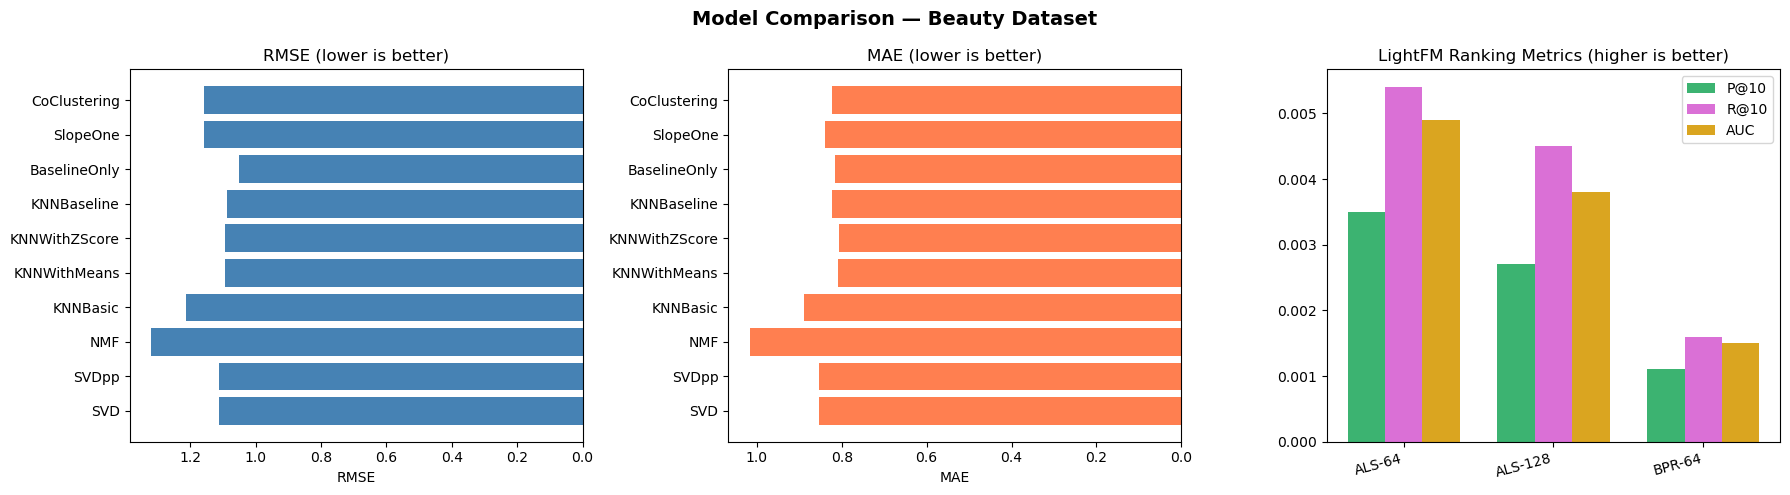

In [27]:
# ── 9a. RMSE / MAE bar charts for Surprise models ────────────────────────────
surprise_df = results_df[results_df['RMSE'].notna()].copy()
lfm_df      = results_df[results_df['P@10'].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — Beauty Dataset', fontsize=14, fontweight='bold')

# RMSE
axes[0].barh(surprise_df['Model'], surprise_df['RMSE'], color='steelblue')
axes[0].set_title('RMSE (lower is better)')
axes[0].set_xlabel('RMSE')
axes[0].invert_xaxis()

# MAE
axes[1].barh(surprise_df['Model'], surprise_df['MAE'], color='coral')
axes[1].set_title('MAE (lower is better)')
axes[1].set_xlabel('MAE')
axes[1].invert_xaxis()

# LightFM ranking metrics
x = np.arange(len(lfm_df))
w = 0.25
axes[2].bar(x - w, lfm_df['P@10'], width=w, label='P@10',  color='mediumseagreen')
axes[2].bar(x,     lfm_df['R@10'], width=w, label='R@10',  color='orchid')
axes[2].bar(x + w, lfm_df['AUC'],  width=w, label='AUC',   color='goldenrod')
axes[2].set_xticks(x)
axes[2].set_xticklabels(lfm_df['Model'], rotation=15, ha='right')
axes[2].set_title('LightFM Ranking Metrics (higher is better)')
axes[2].legend()

plt.tight_layout()
plt.show()

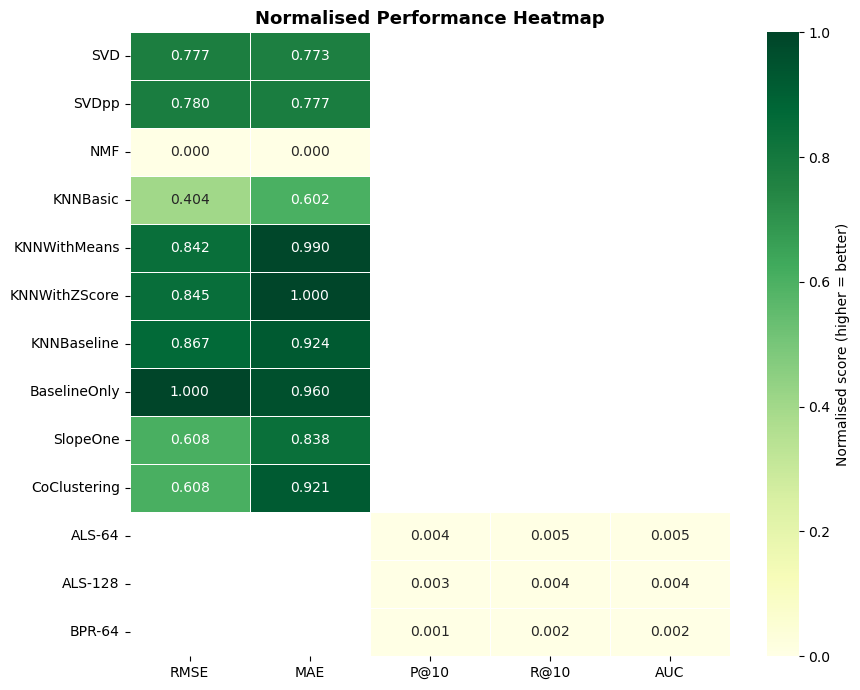


Best model per metric:
  RMSE   → BaselineOnly            (1.0519)
  MAE    → KNNWithZScore           (0.8066)
  P@10   → ALS-64                  (0.0035)
  R@10   → ALS-64                  (0.0054)
  AUC    → ALS-64                  (0.0049)


In [28]:
# ── 9b. Heatmap of all numeric metrics ───────────────────────────────────────
metric_cols = ['RMSE', 'MAE', 'P@10', 'R@10', 'AUC']
heat_df = results_df.set_index('Model')[metric_cols].astype(float)

# Normalise each column to [0,1]; for RMSE/MAE invert so higher = better everywhere
for col in ['RMSE', 'MAE']:
    col_range = heat_df[col].max() - heat_df[col].min()
    if col_range > 0:
        heat_df[col] = 1 - (heat_df[col] - heat_df[col].min()) / col_range

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised score (higher = better)'})
ax.set_title('Normalised Performance Heatmap', fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Pick best model per metric
print("\nBest model per metric:")
for col in metric_cols:
    col_data = results_df[col].dropna()
    if col_data.empty:
        continue
    best_idx  = col_data.idxmin() if col in ['RMSE', 'MAE'] else col_data.idxmax()
    best_name = results_df.loc[best_idx, 'Model']
    best_val  = results_df.loc[best_idx, col]
    print(f"  {col:6s} → {best_name:22s}  ({best_val:.4f})")

Step 10 - Recommendation Generation

In [29]:
# ── 10a. CF Recommendation — top-N items for a user (SVD) ────────────────────
def cf_top_n(model, user_id, df, n=10):
    all_items   = df['ProductId'].unique()
    rated_items = set(df[df['UserId'] == user_id]['ProductId'])
    unseen      = [i for i in all_items if i not in rated_items]
    preds       = [(i, model.predict(user_id, i).est) for i in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:n]

# Demo: pick a user who has rated at least 10 items
active_users = beauty_cf['UserId'].value_counts()
demo_user    = active_users[active_users >= 10].index[0]

print(f"CF recommendations for user: {demo_user}\n")
best_cf_model = trained_surprise['SVD']
top10_cf = cf_top_n(best_cf_model, demo_user, beauty_cf, n=10)

rec_cf_df = pd.DataFrame(top10_cf, columns=['ProductId', 'Predicted Rating'])
rec_cf_df.index = range(1, 11)
display(rec_cf_df)

CF recommendations for user: A2V5R832QCSOMX



,ProductId,Predicted Rating
1,B000052YQ2,5
2,B000052ZAY,5
3,B00008J2XQ,5
4,B000127UUA,5
5,B0001EKWPI,5
6,B0001TODNK,5
7,B0002Z8QHW,5
8,B00062ADJA,5
9,B000674Z8A,5
10,B0006MSVCG,5


In [30]:
# ── 10b. Content-Based Recommendation — similar products (Amazon) ─────────────
def cb_recommend(product_name_query, cb_artifact, n=10):
    idx_series = cb_artifact['index']
    matches    = idx_series[idx_series.str.contains(product_name_query, case=False, na=False)]
    if matches.empty:
        print(f"No product found matching '{product_name_query}'")
        return pd.DataFrame()
    seed_idx   = matches.index[0]
    sim_scores = list(enumerate(cb_artifact['sim_matrix'][seed_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_idx    = [i for i, _ in sim_scores[1: n + 1]]   # skip self
    return amazon.iloc[top_idx][['product_name', 'category', 'rating', 'discounted_price']].reset_index(drop=True)

# Demo query
query = 'Lipstick'
print(f"Content-Based (TF-IDF + Cosine) — products similar to '{query}':\n")
cb_recs = cb_recommend(query, trained_cb['TF-IDF + Cosine'], n=10)
display(cb_recs)

Content-Based (TF-IDF + Cosine) — products similar to 'Lipstick':

No product found matching 'Lipstick'


""


In [31]:
# ── 10c. Implicit CF Recommendation — top-N items for a user ─────────────────
def implicit_top_n(model, user_idx, user_items, n=10):
    ids, scores = model.recommend(user_idx, user_items[user_idx], N=n,
                                  filter_already_liked_items=True)
    return list(zip(ids.tolist(), scores.tolist()))

# Map the demo_user (raw ID) to its integer index in beauty_sparse
demo_user_idx = int(np.where(_le_u.classes_ == demo_user)[0][0]) \
    if demo_user in _le_u.classes_ else 0

print(f"ALS-64 recommendations for user index {demo_user_idx}:\n")
top10_impl = implicit_top_n(trained_impl['ALS-64'], demo_user_idx, beauty_sparse, n=10)

rec_impl_df = pd.DataFrame(top10_impl, columns=['Item Index', 'ALS Score'])
rec_impl_df['ProductId'] = _le_i.inverse_transform(rec_impl_df['Item Index'].astype(int))
rec_impl_df = rec_impl_df[['ProductId', 'ALS Score']].reset_index(drop=True)
rec_impl_df.index = range(1, 11)
display(rec_impl_df)

# ── Side-by-side recap ────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Recommendation summary for user {demo_user}")
print(f"{'='*55}")
print(f"  SVD (CF)   top-5: {[p for p, _ in top10_cf[:5]]}")
print(f"  ALS-64     top-5: {[p for p, _ in top10_impl[:5]]}")

ALS-64 recommendations for user index 25448:



,ProductId,ALS Score
1,B002JPJ2ZS,1.379801
2,B00365DABC,1.045168
3,B000142C1A,1.024985
4,B000YJ2SKM,1.024768
5,B002WTC37A,1.000303
6,B000ZMBSPE,0.994722
7,B000NE6QP6,0.971843
8,B002MSN3QQ,0.963570
9,B00BRGUNV2,0.913652
10,B001CPM03C,0.846153



  Recommendation summary for user A2V5R832QCSOMX
  SVD (CF)   top-5: ['B000052YQ2', 'B000052ZAY', 'B00008J2XQ', 'B000127UUA', 'B0001EKWPI']
  ALS-64     top-5: [8161, 9272, 370, 4237, 8835]


Step 11 - Confusion Matrices

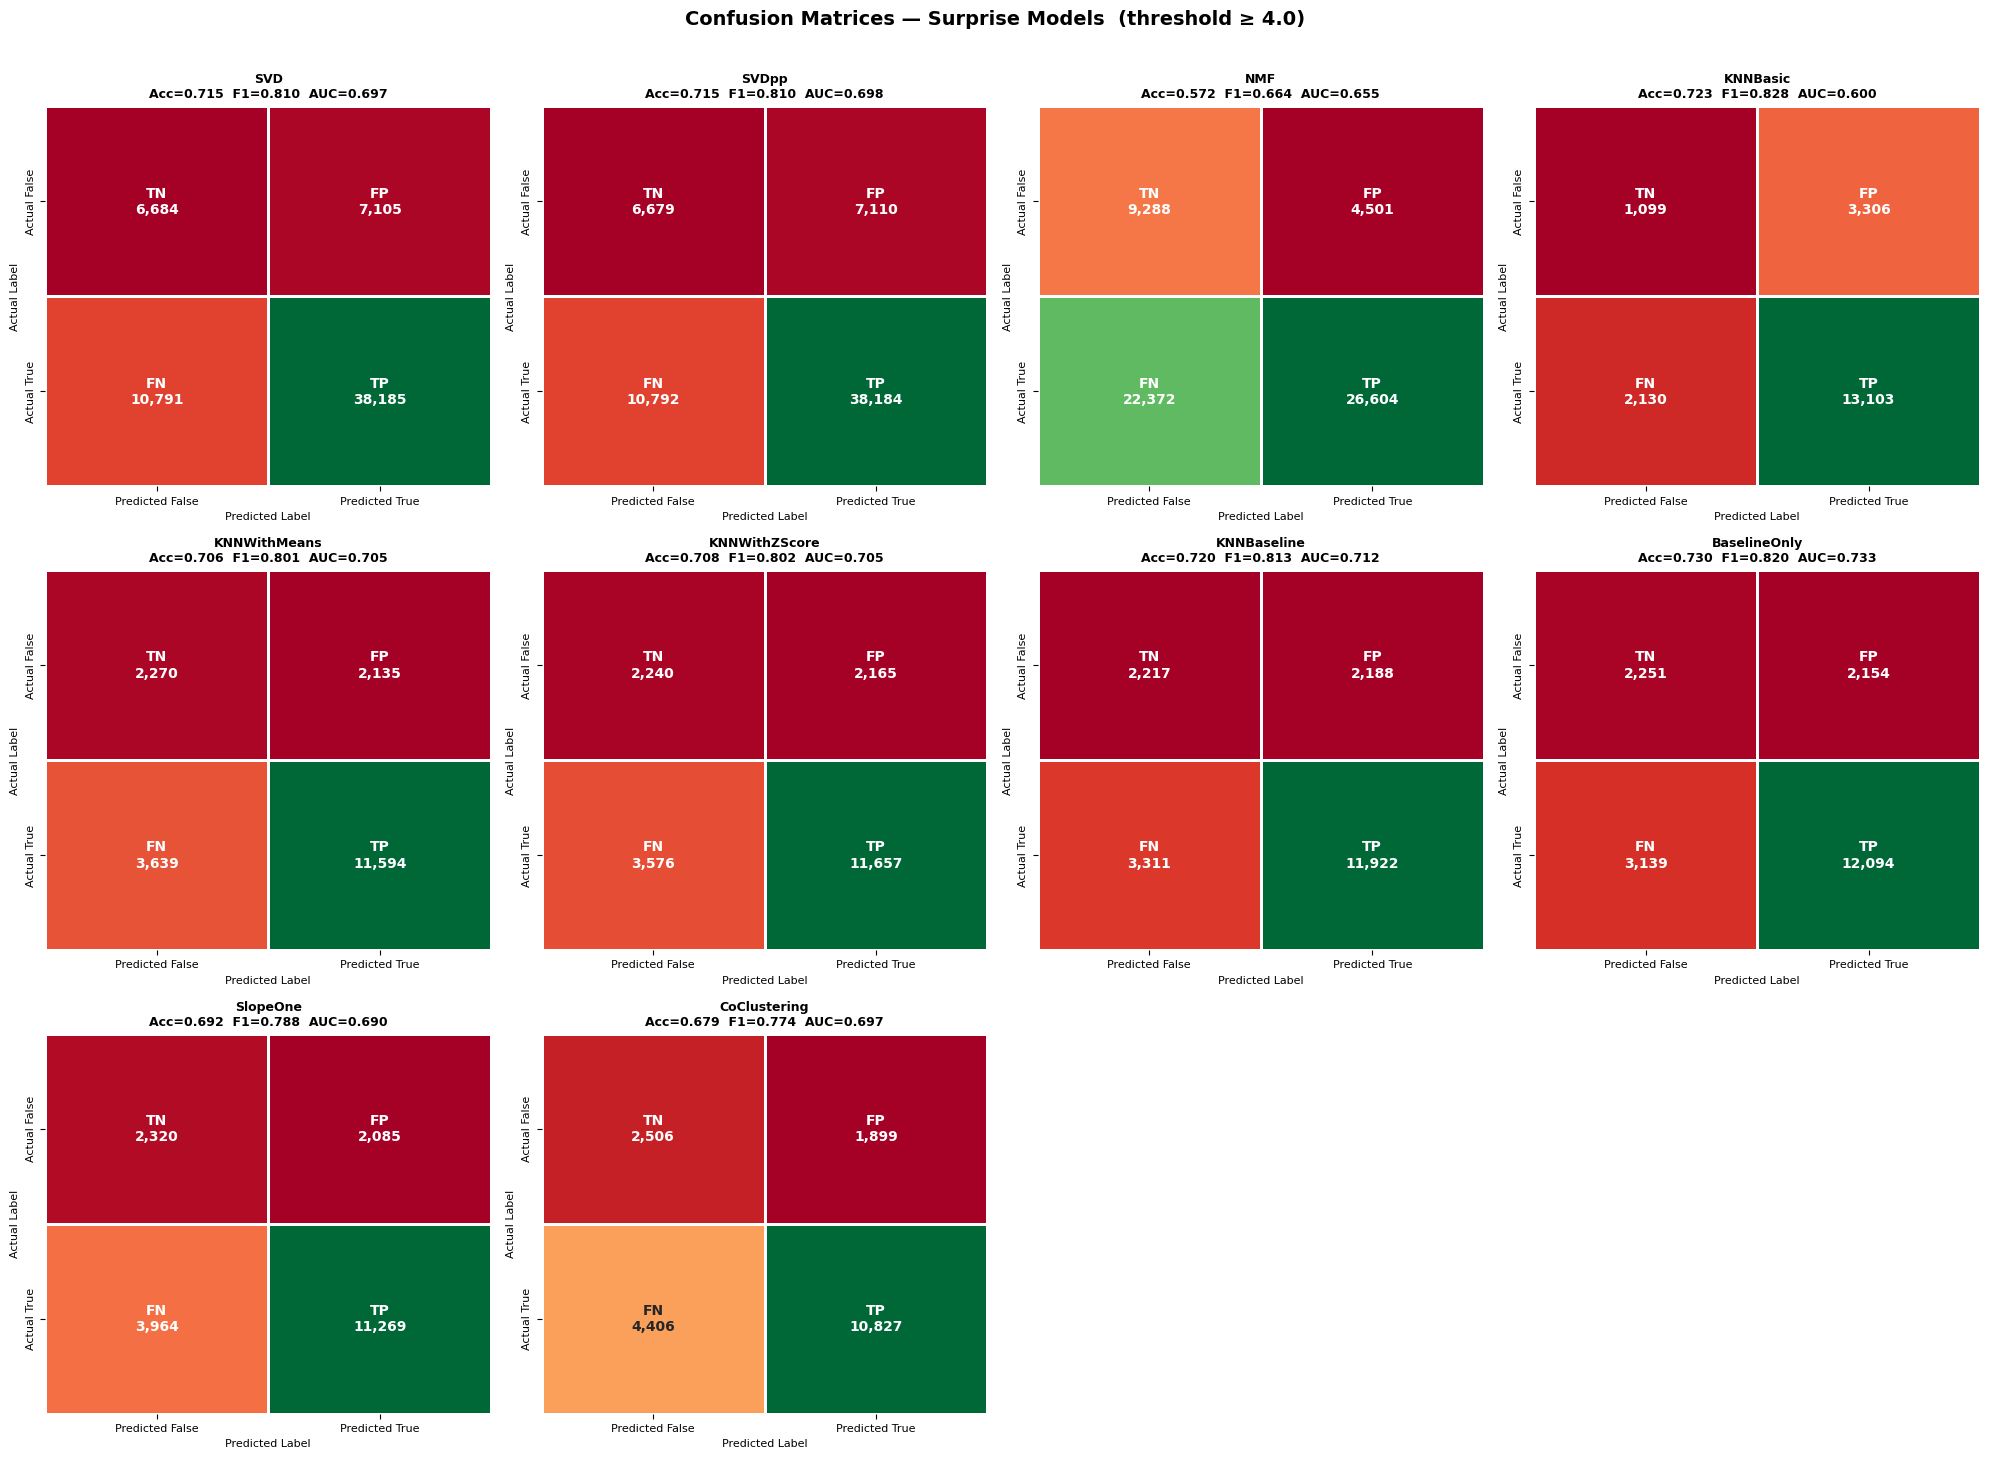

In [36]:
# ── 11a. Confusion matrices for Surprise CF models (True / False labels) ──────
# Binary classification: rating ≥ 4.0 = True (liked), < 4.0 = False (not liked)
# ROC-AUC uses continuous predicted ratings as scores (no thresholding needed).
# MF models → evaluated on testset_beauty (full)
# KNN / Other → evaluated on testset_knn (top-5k subset)

LIKE_THRESHOLD = 4.0

all_surprise_names = list(trained_surprise.keys())
n_models = len(all_surprise_names)
ncols = 4
nrows = -(-n_models // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.8))
fig.suptitle(f'Confusion Matrices — Surprise Models  (threshold ≥ {LIKE_THRESHOLD})',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

cm_records = []

for ax, name in zip(axes, all_surprise_names):
    model   = trained_surprise[name]
    testset = testset_beauty if name in cf_mf_models else testset_knn
    preds   = model.test(testset)

    y_true  = np.array([p.r_ui for p in preds])
    y_score = np.array([p.est  for p in preds])   # continuous → ROC-AUC

    y_true_bin = (y_true  >= LIKE_THRESHOLD).astype(int)
    y_pred_bin = (y_score >= LIKE_THRESHOLD).astype(int)

    cm_m = confusion_matrix(y_true_bin, y_pred_bin)
    tn, fp, fn, tp = cm_m.ravel()

    acc  = accuracy_score(y_true_bin, y_pred_bin)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    try:
        auc = roc_auc_score(y_true_bin, y_score)
    except Exception:
        auc = float('nan')
    mcc_num = float(tp) * float(tn) - float(fp) * float(fn)
    mcc_den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0

    cm_records.append({
        'Model': name,
        'Accuracy': round(acc, 4),    'Precision':   round(prec, 4),
        'Recall':   round(rec, 4),    'Specificity': round(spec, 4),
        'F1':       round(f1, 4),     'ROC-AUC':     round(auc, 4),
        'MCC':      round(mcc, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    })

    # ── TN FP / FN TP layout (matches Step 12 style) ──────────────────────────
    cm_display = np.array([[tn, fp], [fn, tp]])
    annot = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                      [f'FN\n{fn:,}', f'TP\n{tp:,}']])

    sns.heatmap(cm_display, annot=annot, fmt='', cmap='RdYlGn',
                xticklabels=['Predicted False', 'Predicted True'],
                yticklabels=['Actual False',    'Actual True'],
                ax=ax, cbar=False, linewidths=1, linecolor='white',
                annot_kws={'size': 10, 'weight': 'bold'})
    ax.set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=8)
    ax.set_ylabel('Actual Label',    fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Complete Classification Metrics — Surprise Models  (threshold ≥ 4.0)



Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,MCC
SVD,0.7149,0.8431,0.7797,0.4847,0.8102,0.6966,0.2442
SVDpp,0.7148,0.8430,0.7796,0.4844,0.8101,0.6978,0.2439
NMF,0.5718,0.8553,0.5432,0.6736,0.6644,0.6545,0.1795
KNNBasic,0.7232,0.7985,0.8602,0.2495,0.8282,0.5996,0.1234
KNNWithMeans,0.7060,0.8445,0.7611,0.5153,0.8006,0.7053,0.2514
KNNWithZScore,0.7077,0.8434,0.7652,0.5085,0.8024,0.7054,0.2501
KNNBaseline,0.7200,0.8449,0.7826,0.5033,0.8126,0.7119,0.2652
BaselineOnly,0.7305,0.8488,0.7939,0.5110,0.8205,0.7329,0.2850
SlopeOne,0.6920,0.8439,0.7398,0.5267,0.7884,0.6898,0.2383
CoClustering,0.6789,0.8508,0.7108,0.5689,0.7745,0.6973,0.2443


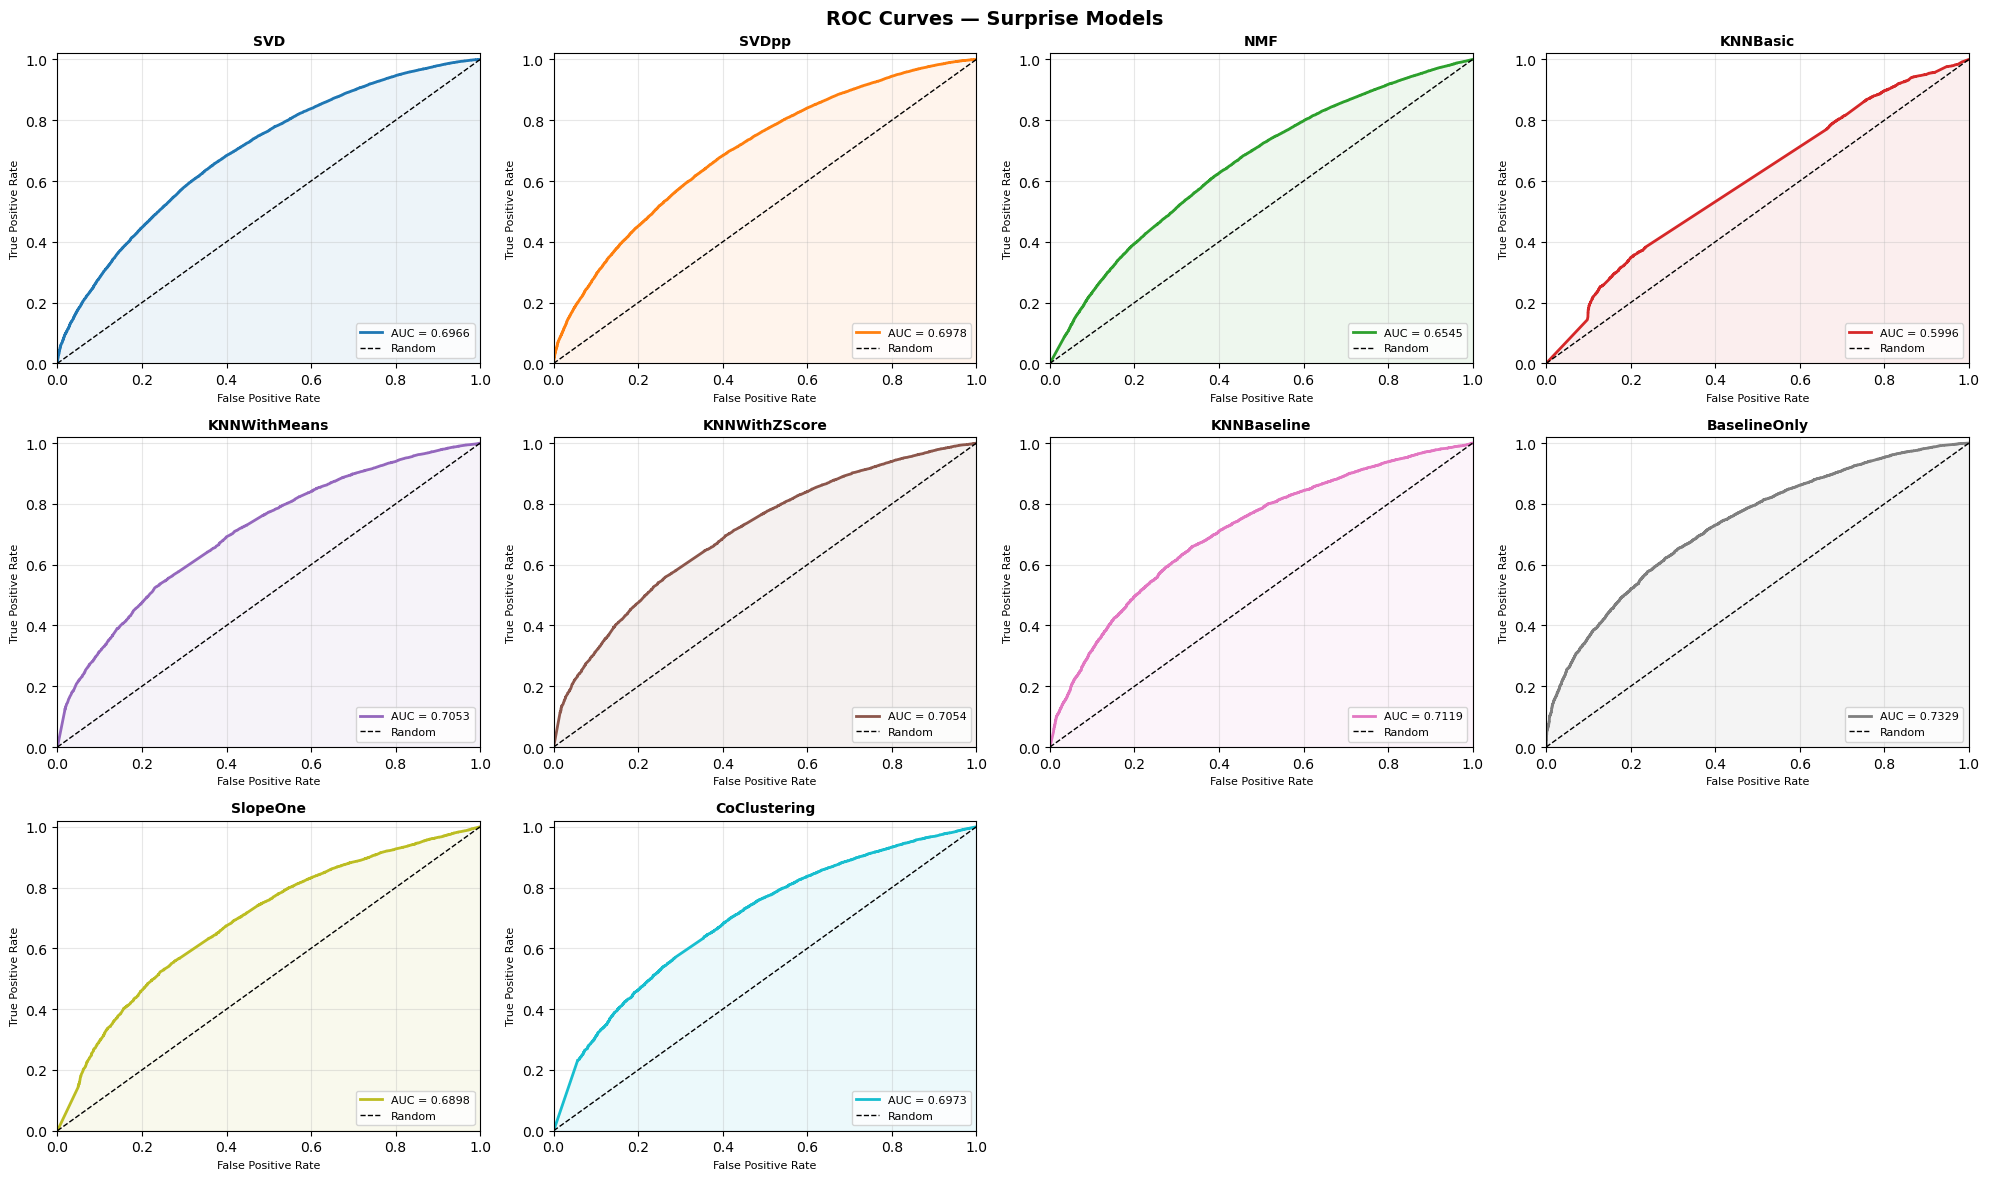

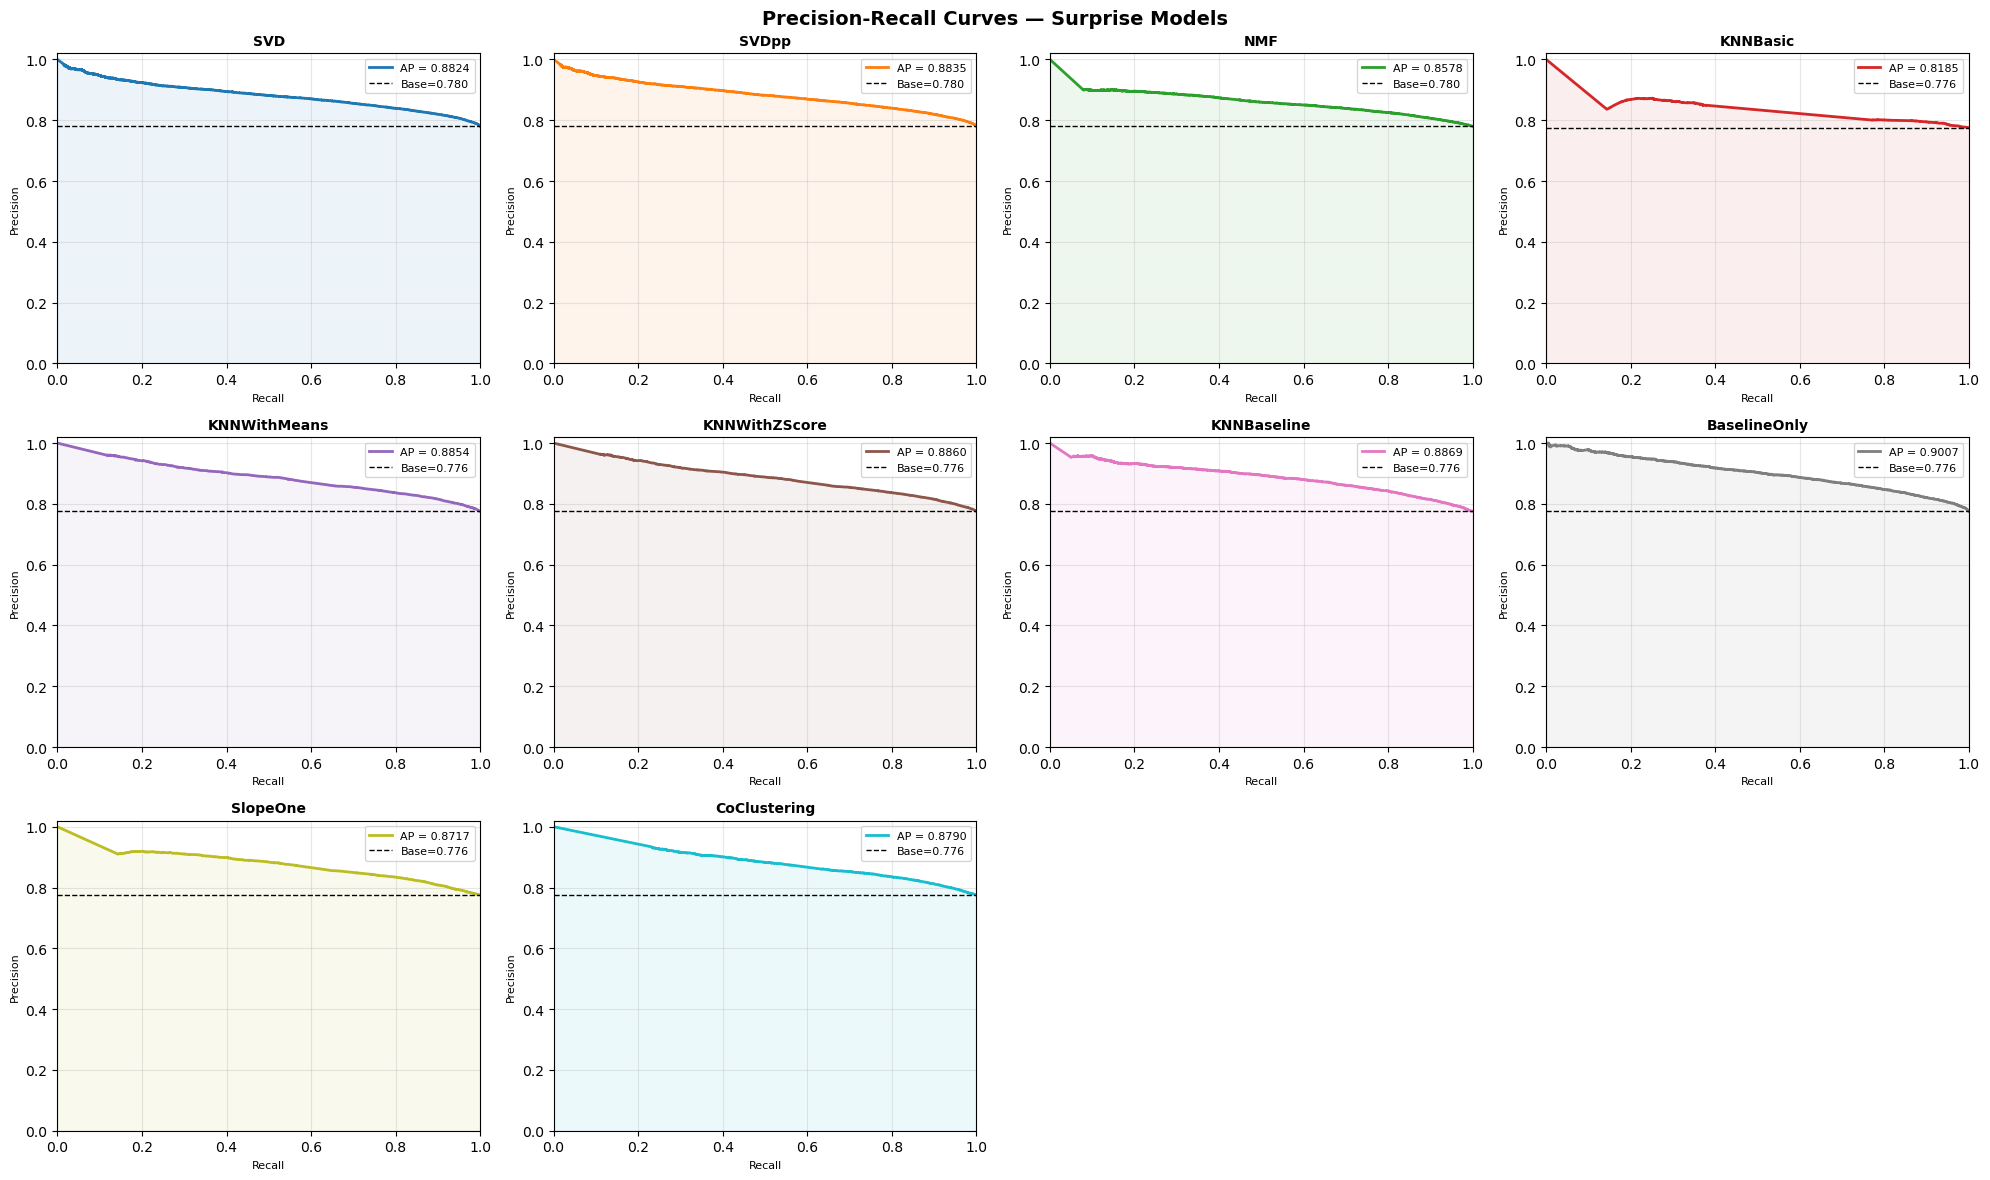

In [37]:
# ── 11b. Surprise models — full metrics table + ROC curves ───────────────────

# ── Comprehensive metrics summary table ───────────────────────────────────────
cm_df = pd.DataFrame(cm_records)

print("Complete Classification Metrics — Surprise Models  (threshold ≥ 4.0)\n")
display(cm_df[['Model','Accuracy','Precision','Recall','Specificity',
               'F1','ROC-AUC','MCC']].style
    .set_caption("Binary Classification Summary — Surprise Models")
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall',
                                    'Specificity','F1','ROC-AUC','MCC']})
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC-AUC','MCC'],
                   color='#c6efce', axis=0)
    .highlight_min(subset=['Accuracy','Precision','Recall','F1','ROC-AUC','MCC'],
                   color='#ffc7ce', axis=0)
    .hide(axis='index')
)

# ── ROC curves for every Surprise model ──────────────────────────────────────
ncols_r = 4
nrows_r = -(-n_models // ncols_r)
fig, axes = plt.subplots(nrows_r, ncols_r, figsize=(ncols_r * 5, nrows_r * 4))
fig.suptitle('ROC Curves — Surprise Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = plt.cm.tab10(np.linspace(0, 1, n_models))

for ax, name, color in zip(axes, all_surprise_names, palette):
    model   = trained_surprise[name]
    testset = testset_beauty if name in cf_mf_models else testset_knn
    preds   = model.test(testset)

    y_true  = np.array([p.r_ui for p in preds])
    y_score = np.array([p.est  for p in preds])
    y_true_bin = (y_true >= LIKE_THRESHOLD).astype(int)

    try:
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        auc_val = roc_auc_score(y_true_bin, y_score)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_val:.4f}')
        ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    except Exception:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=8)
    ax.set_ylabel('True Positive Rate',  fontsize=8)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# ── Precision-Recall curves ───────────────────────────────────────────────────
fig2, axes2 = plt.subplots(nrows_r, ncols_r, figsize=(ncols_r * 5, nrows_r * 4))
fig2.suptitle('Precision-Recall Curves — Surprise Models', fontsize=14, fontweight='bold')
axes2 = axes2.flatten()

for ax, name, color in zip(axes2, all_surprise_names, palette):
    model   = trained_surprise[name]
    testset = testset_beauty if name in cf_mf_models else testset_knn
    preds   = model.test(testset)

    y_true  = np.array([p.r_ui for p in preds])
    y_score = np.array([p.est  for p in preds])
    y_true_bin = (y_true >= LIKE_THRESHOLD).astype(int)
    baseline   = y_true_bin.mean()

    try:
        prec_c, rec_c, _ = precision_recall_curve(y_true_bin, y_score)
        ap_val = average_precision_score(y_true_bin, y_score)
        ax.plot(rec_c, prec_c, color=color, lw=2, label=f'AP = {ap_val:.4f}')
        ax.fill_between(rec_c, prec_c, alpha=0.08, color=color)
    except Exception:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)

    ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Base={baseline:.3f}')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall',    fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

for ax in axes2[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Step 12 - Implicit CF Models Full Evaluation (replaces LightFM — ALS / BPR)

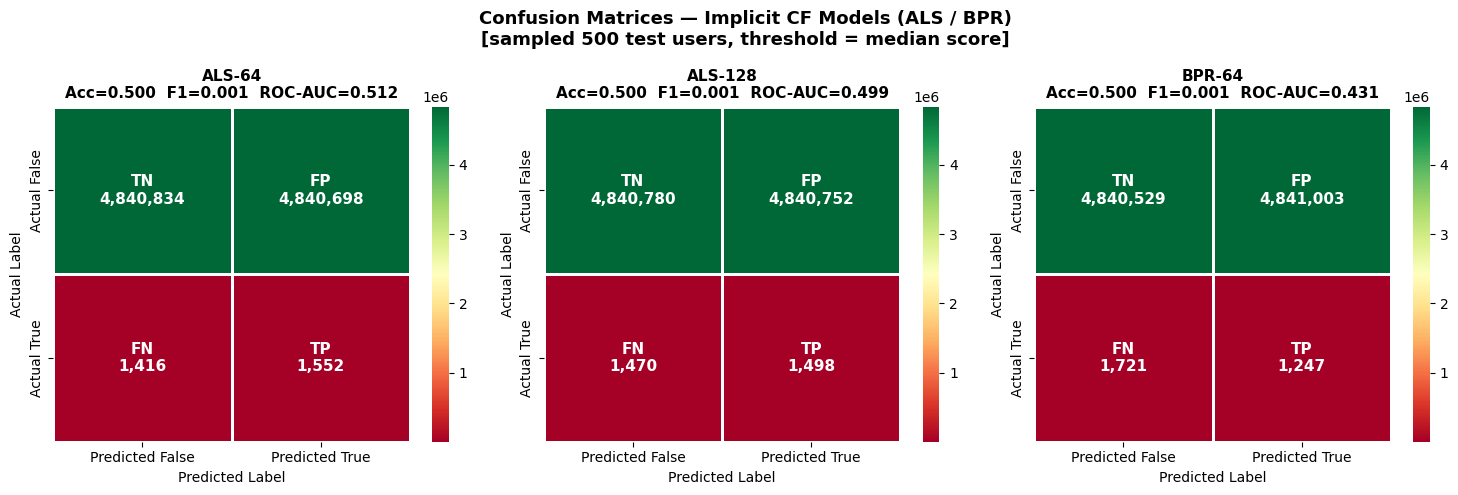

In [34]:
# ── 12a. Confusion matrices with True / False labels ─────────────────────────
# For each test user:
#   Positive (True)  = item the user interacted with in the test set
#   Negative (False) = item the user did NOT interact with in the test set
# We score every item using the model's latent factors and threshold at the
# median score to produce binary predictions, then build the confusion matrix.
# ROC-AUC uses the raw continuous scores (no thresholding needed).

SAMPLE_USERS = 500   # sample for speed — scoring all items per user is O(n_items)
np.random.seed(42)

test_coo = test_impl.tocoo()
test_items_by_user = defaultdict(set)
for u, i in zip(test_coo.row, test_coo.col):
    test_items_by_user[u].add(i)

eligible = [u for u, items in test_items_by_user.items()
            if u < train_impl.shape[0] and len(items) > 0]
sampled_users = np.random.choice(eligible,
                                  size=min(SAMPLE_USERS, len(eligible)),
                                  replace=False)

n_items = train_impl.shape[1]
all_item_ids = np.arange(n_items)

fig, axes = plt.subplots(1, len(trained_impl), figsize=(len(trained_impl) * 5, 5))
if len(trained_impl) == 1:
    axes = [axes]

full_metrics = []

for ax, (mname, model) in zip(axes, trained_impl.items()):
    user_f = np.array(model.user_factors)
    item_f = np.array(model.item_factors)

    all_y_true, all_y_score = [], []

    for uid in sampled_users:
        relevant = test_items_by_user[uid]
        scores   = user_f[uid] @ item_f.T          # continuous score for every item
        y_true   = np.isin(all_item_ids, list(relevant)).astype(int)
        all_y_true.extend(y_true.tolist())
        all_y_score.extend(scores.tolist())

    all_y_true  = np.array(all_y_true)
    all_y_score = np.array(all_y_score)

    # threshold at median to get binary predictions
    threshold   = np.median(all_y_score)
    all_y_pred  = (all_y_score >= threshold).astype(int)

    # ── metrics ──────────────────────────────────────────────────────────────
    cm_m   = confusion_matrix(all_y_true, all_y_pred)
    tn, fp, fn, tp = cm_m.ravel()
    acc    = accuracy_score(all_y_true, all_y_pred)
    prec   = precision_score(all_y_true, all_y_pred, zero_division=0)
    rec    = recall_score(all_y_true, all_y_pred, zero_division=0)
    f1     = f1_score(all_y_true, all_y_pred, zero_division=0)
    auc    = roc_auc_score(all_y_true, all_y_score)
    ap     = average_precision_score(all_y_true, all_y_score)
    spec   = tn / (tn + fp) if (tn + fp) > 0 else 0   # specificity
    mcc_num = tp * tn - fp * fn
    mcc_den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc    = mcc_num / mcc_den if mcc_den > 0 else 0

    full_metrics.append({
        'Model': mname, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'Specificity': round(spec, 4),
        'F1': round(f1, 4), 'ROC-AUC': round(auc, 4),
        'Avg Precision': round(ap, 4), 'MCC': round(mcc, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    })

    # ── confusion matrix with True / False labels ─────────────────────────────
    cm_display = np.array([[tn, fp], [fn, tp]])
    labels = ['False (Neg)', 'True (Pos)']
    annot  = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                        [f'FN\n{fn:,}', f'TP\n{tp:,}']])

    sns.heatmap(cm_display, annot=annot, fmt='', cmap='RdYlGn',
                xticklabels=['Predicted False', 'Predicted True'],
                yticklabels=['Actual False',    'Actual True'],
                ax=ax, cbar=True, linewidths=1, linecolor='white',
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'{mname}\nAcc={acc:.3f}  F1={f1:.3f}  ROC-AUC={auc:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('Actual Label',    fontsize=10)

fig.suptitle('Confusion Matrices — Implicit CF Models (ALS / BPR)\n'
             f'[sampled {SAMPLE_USERS} test users, threshold = median score]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Complete Metrics — Implicit CF Models (ALS / BPR)



Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,Avg Precision,MCC
ALS-64,0.5000,0.0003,0.5229,0.5000,0.0006,0.5123,0.0006,0.2538
ALS-128,0.5000,0.0003,0.5047,0.5000,0.0006,0.4995,0.0005,0.0522
BPR-64,0.5000,0.0003,0.4201,0.5000,0.0005,0.4306,0.0004,-0.8845


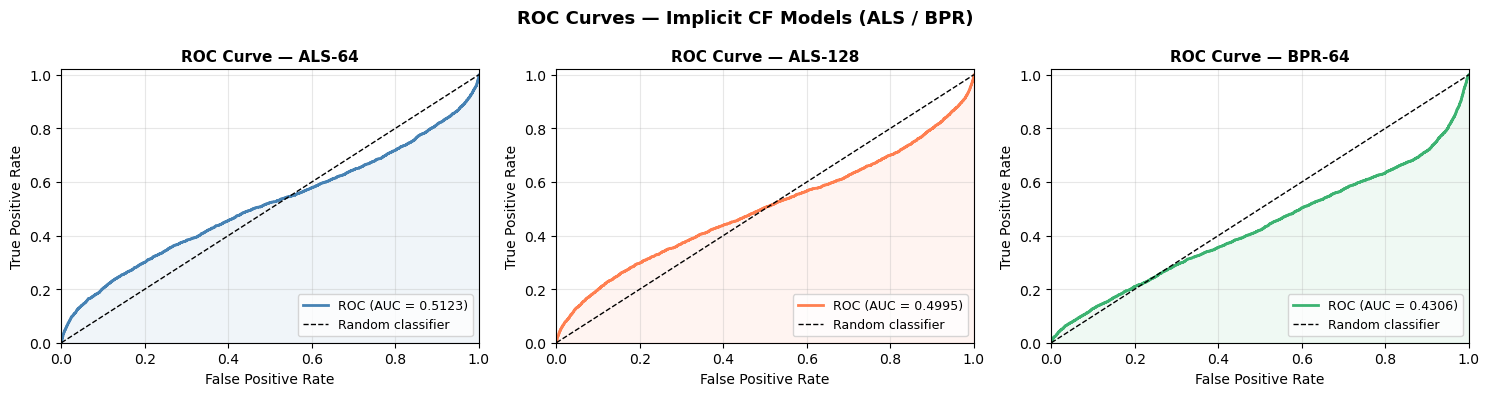

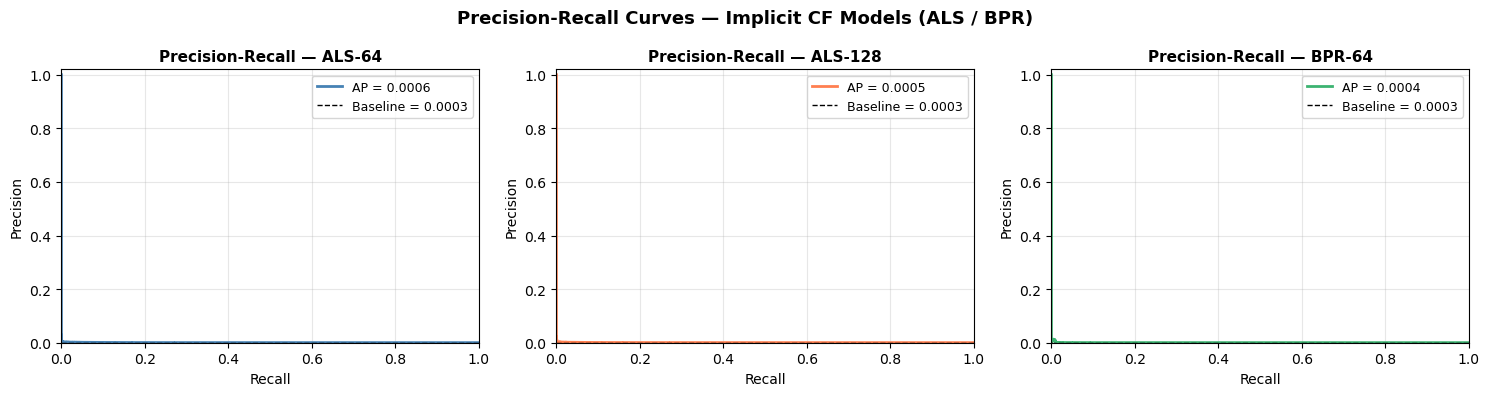

In [35]:
# ── 12b. Full metrics table + ROC curves ─────────────────────────────────────
metrics_df = pd.DataFrame(full_metrics)

print("Complete Metrics — Implicit CF Models (ALS / BPR)\n")
display(metrics_df[['Model','Accuracy','Precision','Recall','Specificity',
                     'F1','ROC-AUC','Avg Precision','MCC']].style
    .set_caption("Implicit CF Models — Full Classification Metrics")
    .format({c: '{:.4f}' for c in ['Accuracy','Precision','Recall','Specificity',
                                    'F1','ROC-AUC','Avg Precision','MCC']})
    .highlight_max(subset=['Accuracy','Precision','Recall','F1',
                            'ROC-AUC','Avg Precision','MCC'],
                   color='#c6efce', axis=0)
    .highlight_min(subset=['Accuracy','Precision','Recall','F1',
                            'ROC-AUC','Avg Precision','MCC'],
                   color='#ffc7ce', axis=0)
    .hide(axis='index')
)

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(trained_impl), figsize=(len(trained_impl) * 5, 4))
if len(trained_impl) == 1:
    axes = [axes]

colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, (mname, model), color in zip(axes, trained_impl.items(), colors):
    user_f = np.array(model.user_factors)
    item_f = np.array(model.item_factors)

    all_y_true, all_y_score = [], []
    for uid in sampled_users:
        relevant   = test_items_by_user[uid]
        scores     = user_f[uid] @ item_f.T
        y_true     = np.isin(all_item_ids, list(relevant)).astype(int)
        all_y_true.extend(y_true.tolist())
        all_y_score.extend(scores.tolist())

    all_y_true  = np.array(all_y_true)
    all_y_score = np.array(all_y_score)

    fpr, tpr, _ = roc_curve(all_y_true, all_y_score)
    auc_val     = roc_auc_score(all_y_true, all_y_score)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC (AUC = {auc_val:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'ROC Curve — {mname}', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Implicit CF Models (ALS / BPR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Precision-Recall curves ───────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(trained_impl), figsize=(len(trained_impl) * 5, 4))
if len(trained_impl) == 1:
    axes2 = [axes2]

for ax, (mname, model), color in zip(axes2, trained_impl.items(), colors):
    user_f = np.array(model.user_factors)
    item_f = np.array(model.item_factors)

    all_y_true, all_y_score = [], []
    for uid in sampled_users:
        relevant   = test_items_by_user[uid]
        scores     = user_f[uid] @ item_f.T
        y_true     = np.isin(all_item_ids, list(relevant)).astype(int)
        all_y_true.extend(y_true.tolist())
        all_y_score.extend(scores.tolist())

    all_y_true  = np.array(all_y_true)
    all_y_score = np.array(all_y_score)
    baseline    = all_y_true.mean()

    prec_c, rec_c, _ = precision_recall_curve(all_y_true, all_y_score)
    ap_val            = average_precision_score(all_y_true, all_y_score)

    ax.plot(rec_c, prec_c, color=color, lw=2, label=f'AP = {ap_val:.4f}')
    ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.4f}')
    ax.fill_between(rec_c, prec_c, alpha=0.08, color=color)
    ax.set_title(f'Precision-Recall — {mname}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle('Precision-Recall Curves — Implicit CF Models (ALS / BPR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Step 13 - Model Persistence (Save Best Model for Web App)

In [38]:
import pickle, os
from datetime import datetime

# ── Output directory ───────────────────────────────────────────────────────────
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Build the lookup: user → set of product IDs already rated ─────────────────
# The web app uses this to exclude items the user has already seen.
user_rated_items = (
    beauty_knn.groupby('UserId')['ProductId']
    .apply(set)
    .to_dict()
)

# ── All product IDs the model knows about ─────────────────────────────────────
# Needed by the web app to score unseen items for a given user.
all_product_ids = beauty_knn['ProductId'].unique().tolist()

# ── Bundle everything the web app needs into one object ───────────────────────
model_bundle = {
    # The trained model
    'model':            trained_surprise['KNNBaseline'],

    # Surprise trainset — required internally by model.predict()
    'trainset':         trainset_knn,

    # All product IDs the model can recommend
    'all_product_ids':  all_product_ids,

    # Per-user rated products — filter these out at inference time
    'user_rated_items': user_rated_items,

    # Metadata
    'metadata': {
        'model_name':       'KNNBaseline',
        'model_type':       'Hybrid CF (KNN Neighbourhood + Baseline)',
        'library':          'scikit-surprise',
        'dataset':          'Amazon Beauty (top-5000 active users)',
        'n_ratings':        len(beauty_knn),
        'n_users':          beauty_knn['UserId'].nunique(),
        'n_products':       beauty_knn['ProductId'].nunique(),
        'rating_scale':     (1, 5),
        'like_threshold':   4.0,
        'rmse':             1.0875,
        'mae':              0.8225,
        'saved_at':         datetime.now().isoformat(),
    }
}

# ── Save ───────────────────────────────────────────────────────────────────────
save_path = os.path.join(SAVE_DIR, 'knnbaseline_recommender.pkl')

with open(save_path, 'wb') as f:
    pickle.dump(model_bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

size_mb = os.path.getsize(save_path) / (1024 ** 2)
print(f"Model saved  →  {save_path}")
print(f"File size    :  {size_mb:.2f} MB")
print(f"\nBundle contents:")
for key, val in model_bundle.items():
    if key == 'metadata':
        for k, v in val.items():
            print(f"  metadata.{k:18s}: {v}")
    else:
        desc = (f"{len(val):,} items" if isinstance(val, (list, dict)) else type(val).__name__)
        print(f"  {key:22s}: {desc}")

# ── Verify: reload and run a test prediction ───────────────────────────────────
print("\n── Verification (reload from disk) ──────────────────────────────────────")
with open(save_path, 'rb') as f:
    loaded = pickle.load(f)

m      = loaded['model']
ts     = loaded['trainset']
demo_u = list(loaded['user_rated_items'].keys())[0]
demo_p = all_product_ids[0]

pred = m.predict(demo_u, demo_p)
print(f"  Test predict  user={demo_u}  product={demo_p}")
print(f"  Estimated rating : {pred.est:.4f}")
print(f"\nModel saved successfully.")

Model saved  →  models\knnbaseline_recommender.pkl
File size    :  194.10 MB

Bundle contents:
  model                 : KNNBaseline
  trainset              : Trainset
  all_product_ids       : 16,931 items
  user_rated_items      : 5,000 items
  metadata.model_name        : KNNBaseline
  metadata.model_type        : Hybrid CF (KNN Neighbourhood + Baseline)
  metadata.library           : scikit-surprise
  metadata.dataset           : Amazon Beauty (top-5000 active users)
  metadata.n_ratings         : 98188
  metadata.n_users           : 5000
  metadata.n_products        : 16931
  metadata.rating_scale      : (1, 5)
  metadata.like_threshold    : 4.0
  metadata.rmse              : 1.0875
  metadata.mae               : 0.8225
  metadata.saved_at          : 2026-05-04T19:09:29.323781

── Verification (reload from disk) ──────────────────────────────────────
  Test predict  user=A00700212KB3K0MVESPIY  product=7806397051
  Estimated rating : 4.5185

Model saved successfully.
